# Bölüm 2: Python ile Sayısal (Numerical) MLE

In [3]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

def negative_log_likelihood(lam, data):
    """
    Poisson dağılımı için Negatif Log-Likelihood hesaplar.
    İpucu: log(k!) terimi optimizasyon sırasında sabit olduğu için ihmal edilebilir.
    """
    n = len(data)
    # NLL formülü: n*lambda - log(lambda) * sum(k)
    nll = n * lam - np.log(lam) * np.sum(data)
    return nll

# Başlangıç tahmini
initial_guess = np.array([1.0])

# Optimizasyon: NLL'yi minimize etmek, Likelihood'u maximize etmektir.
result = opt.minimize(negative_log_likelihood, initial_guess, args=(traffic_data,), bounds=[(0.001, None)])

print(f"Sayısal Tahmin (MLE lambda): {result.x[0]:.4f}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data):.4f}")

Sayısal Tahmin (MLE lambda): 12.1429
Analitik Tahmin (Ortalama): 12.1429


# Bölüm 3: Model Karşılaştırma ve Görselleştirme

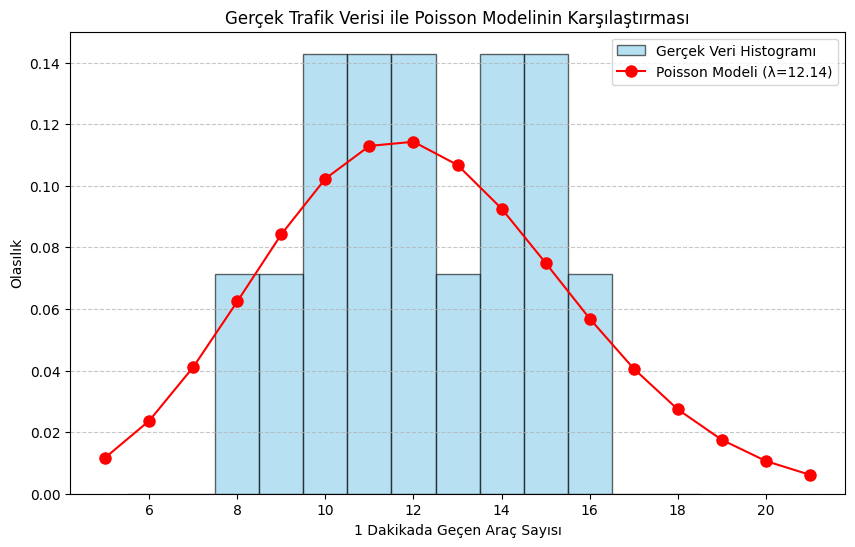

In [4]:
from scipy.stats import poisson

# Önceki hücrede bulduğumuz lambda değerini (12.14) alıyoruz
lam = result.x[0]

# Grafik boyutunu ayarlayalım
plt.figure(figsize=(10, 6))

# 1. Gerçek Verinin Histogramı
# density=True yapıyoruz ki çubuklar olasılık belirtsin ve çizgi grafiğiyle uyumlu olsun
plt.hist(traffic_data, bins=np.arange(6, 20)-0.5, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Gerçek Veri Histogramı')

# 2. Poisson PMF Grafiği (Bizim kurduğumuz model)
x_degerleri = np.arange(5, 22) # Ekranda göstereceğimiz araç sayısı aralığı
pmf_degerleri = poisson.pmf(x_degerleri, lam) # Poisson formülüne göre olasılıkları hesapla

# Modeli kırmızı yuvarlaklar ve çizgi ile çizdiriyoruz
plt.plot(x_degerleri, pmf_degerleri, 'ro-', ms=8, label=f'Poisson Modeli (λ={lam:.2f})')

# Zorunlu Etiketler
plt.xlabel("1 Dakikada Geçen Araç Sayısı")
plt.ylabel("Olasılık")
plt.title("Gerçek Trafik Verisi ile Poisson Modelinin Karşılaştırması")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ekrana bas!
plt.show()